<div class="jupyter-biolm-header">
    <img style="float: left; padding-right: 10px; height: 60px" src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/logo.png">
    <p>
    <br>
    <br>
    <br>
    </p>
</div>

# Filter Designs by Fold Quality Before Running Stability and Solubility Predictions

Use ESMFold confidence scores as a coarse gate before downstream property predictions.

<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://www.svgrepo.com/show/354202/postman-icon.svg" style="height: 15px; float: left; padding-right: 10px;"><a href="https://api.biolm.ai/">  <h5 style="margin: 0;"><b>Postman API Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/Python-logo-notext.svg/1869px-Python-logo-notext.svg.png" style="height: 15px; float: left; padding-right: 10px;"><a href="https://docs.biolm.ai/en/latest/index.html"><h5 style="margin: 0;"><b>Python SDK Docs</b></h5></a>
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
        </td>
    </tr>
</table>

<br>

---

**What you'll learn:**
- Using ESMFold as a fast fold quality filter
- Interpreting pLDDT and pTM confidence scores
- Building a three-gate pipeline: fold → stability → solubility
- When to use and when to skip the fold gate

**Requirements:**
```
pip install biolmai matplotlib
export BIOLMAI_TOKEN=your-token-here
```

> **Note:** This notebook requires ESMFold access via the BioLM API.
> Confirm availability at [biolm.ai/models](https://biolm.ai/models).

## Setup

In [1]:
import os
from biolmai.pipeline import (
    DataPipeline, DuckDBDataStore,
    ThresholdFilter, RankingFilter,
    ValidAminoAcidFilter, EmbeddingSpec,
    DiversitySamplingFilter,
)

TOKEN = os.environ.get("BIOLMAI_TOKEN", "")
if not TOKEN:
    raise EnvironmentError(
        "Set BIOLMAI_TOKEN before running.\n"
        "Get one at https://biolm.ai/ui/accounts/user-api-tokens/"
    )
import matplotlib.pyplot as plt

## Designed library

A mixed library of designed sequences — some will fold well, some won't.

In [2]:
DESIGNED_LIBRARY = [
    # Well-folded scaffolds (expected high pLDDT)
    "MKTAYIAKQRQISFVKSHFSRQLEERVKILEQELEKAKEELKERLEELEKAKEEL",
    "GSHMDELYKAALEKAKQELKEAKQELKEAKQELKEAKQELKEAKQELKEAKQEL",
    "MHHHHHHSSGENLYFQGAEAAAKEAAAKEAAAKEAAAKEAAAKEAAAKEAAAK",
    "EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLEWVARI",
    "DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKLLIY",
    # Likely disordered / low confidence
    "GSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGSGS",
    "AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA",
    "GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG",
    "KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK",
    "EEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE",
    # Mixed
    "GIGKFLHSAKKFGKAFVGEIMNS",
    "KWKLFKKIPKFLHLAKKF",
    "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES",
]
print(f"{len(DESIGNED_LIBRARY)} sequences in designed library")

13 sequences in designed library


## The fold-first pipeline

Three gates in sequence:
1. **ESMFold** — fast coarse fold quality filter
2. **Melting temperature** — thermal stability (only runs on sequences that pass the fold gate)
3. **Solubility ranking** — final selection (only runs on sequences that pass both gates)

In [3]:
pipeline = DataPipeline(sequences=DESIGNED_LIBRARY, verbose=True)

# Gate 1: coarse fold quality (fast, no MSA)
pipeline.add_prediction(
    "esmfold", extractions=["mean_plddt", "ptm"],
    columns={"mean_plddt": "plddt", "ptm": "ptm"},
    stage_name="fold_coarse",
)
pipeline.add_filter(
    ThresholdFilter("plddt", min_value=65.0),
    stage_name="fold_gate",
)

# Gate 2: stability (only for fold-passing sequences)
pipeline.add_prediction(
    "temberture-regression", extractions="prediction",
    columns="melting_temperature", stage_name="tm",
    depends_on=["fold_gate"],
)
pipeline.add_filter(
    ThresholdFilter("melting_temperature", min_value=50.0),
    stage_name="tm_gate",
)

# Gate 3: solubility ranking
pipeline.add_prediction(
    "biolmsol", extractions="solubility_score",
    columns="solubility", stage_name="sol",
    depends_on=["tm_gate"],
)
pipeline.add_filter(
    RankingFilter("solubility", n=5, ascending=False),
    stage_name="top_5",
)

pipeline.run()

Added stage: PredictionStage('fold_coarse')
Added stage: FilterStage('fold_gate', depends_on=['fold_coarse'])
Added stage: PredictionStage('tm', depends_on=['fold_gate'])
Added stage: FilterStage('tm_gate', depends_on=['tm'])
Added stage: PredictionStage('sol', depends_on=['tm_gate'])
Added stage: FilterStage('top_5', depends_on=['sol'])



############################################################
# Pipeline: DataPipeline
# Run ID: 20260617_104604_5b474b35
# Initial sequences: 13
# Streaming: ENABLED
############################################################

Execution plan: 6 level(s)
  Level 1: fold_coarse
  Level 2: fold_gate
  Level 3: tm
  Level 4: tm_gate
  Level 5: sol
  Level 6: top_5

[Stage: fold_coarse] (streaming to fold_gate)
  Cached: 0/13
  To compute: 13 (streaming)


  fold_coarse: processed 13 sequences
  fold_gate: 10 passed filter (filtered 3)

[Stage: tm] (streaming to tm_gate)
  Cached: 0/10
  To compute: 10 (streaming)


  tm: processed 10 sequences
  tm_gate: 10 passed filter (filtered 0)

Stage: sol
Input: 10 sequences
Depends on: tm_gate
  Cached: 0/10
  To compute: 10
  Calling biolmsol.predict...


  Completed: 10 sequences in 1 batches (max 5 concurrent)

StageResult(sol: in=10, out=10, cached=0, computed=10, filtered=0, time=11.0s)

Stage: top_5
Input: 10 sequences
Depends on: sol
  Applying filter: RankingFilter(column='solubility', n=5, method='top')
  Filtered out: 5/10
  Remaining: 5

StageResult(top_5: in=10, out=5, cached=0, computed=0, filtered=5, time=0.0s)

############################################################
# Pipeline completed in 117.0s
# Final sequences: 5
############################################################



{'fold_coarse': StageResult(fold_coarse: in=13, out=13, cached=0, computed=0, filtered=0, time=0.0s),
 'fold_gate': StageResult(fold_gate: in=13, out=10, cached=0, computed=0, filtered=3, time=0.0s),
 'tm': StageResult(tm: in=10, out=10, cached=0, computed=0, filtered=0, time=0.0s),
 'tm_gate': StageResult(tm_gate: in=10, out=10, cached=0, computed=0, filtered=0, time=0.0s),
 'sol': StageResult(sol: in=10, out=10, cached=0, computed=10, filtered=0, time=11.0s),
 'top_5': StageResult(top_5: in=10, out=5, cached=0, computed=0, filtered=5, time=0.0s)}

In [4]:
pipeline.summary()

,Stage,Input,Output,Filtered,Cached,Computed,Time (s)
0,fold_coarse,13,13,0,0,0,0.0
1,fold_gate,13,10,3,0,0,0.0
2,tm,10,10,0,0,0,0.0
3,tm_gate,10,10,0,0,0,0.0
4,sol,10,10,0,0,10,11.0
5,top_5,10,5,5,0,0,0.0


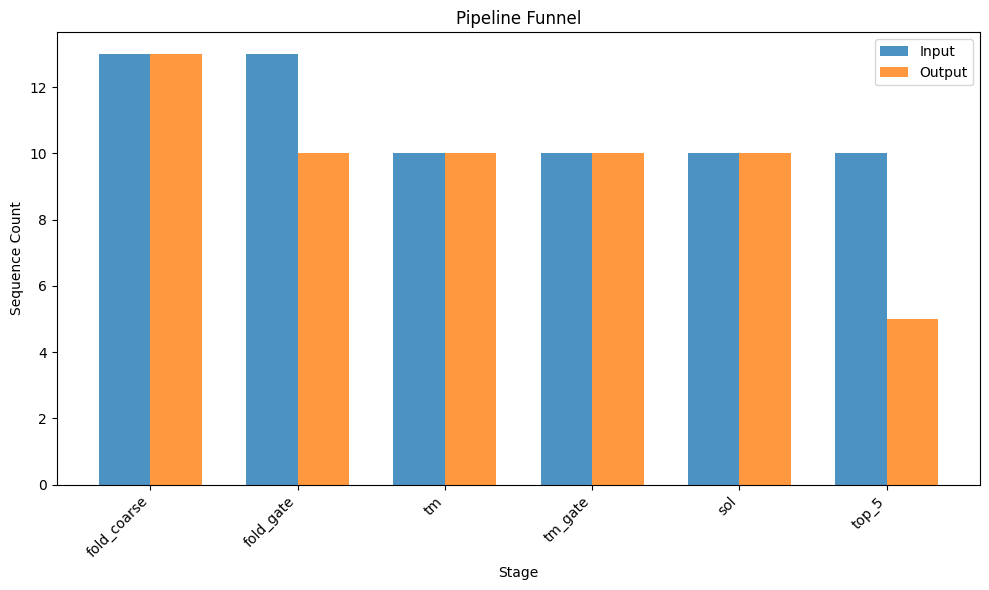

In [5]:
pipeline.plot("funnel")

## Inspect fold quality scores

In [6]:
fold_df = pipeline.query("""
    SELECT s.sequence,
           MAX(CASE WHEN p.prediction_type = 'plddt' THEN ROUND(p.value,1) END) AS plddt,
           MAX(CASE WHEN p.prediction_type = 'ptm'   THEN ROUND(p.value,3) END) AS ptm
    FROM sequences s
    JOIN predictions p ON s.sequence_id = p.sequence_id
    WHERE p.prediction_type IN ('plddt', 'ptm')
    GROUP BY s.sequence
    ORDER BY plddt DESC
""")
fold_df

,sequence,plddt,ptm
0,EEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE...,97.2,0.858
1,GSHMDELYKAALEKAKQELKEAKQELKEAKQELKEAKQELKEAKQE...,87.6,0.699
2,KKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKKK...,86.3,0.639
3,GIGKFLHSAKKFGKAFVGEIMNS,86.3,0.294
4,DIQMTQSPSSLSASVGDRVTITCRASQSISSYLNWYQQKPGKAPKLLIY,86.2,0.646
5,EVQLVESGGGLVQPGGSLRLSCAASGFNIKDTYIHWVRQAPGKGLE...,85.2,0.642
6,MKTAYIAKQRQISFVKSHFSRQLEERVKILEQELEKAKEELKERLE...,84.3,0.635
7,KWKLFKKIPKFLHLAKKF,80.4,0.030
8,MHHHHHHSSGENLYFQGAEAAAKEAAAKEAAAKEAAAKEAAAKEAA...,76.5,0.556
9,LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES,73.7,0.455


## When to use (and skip) the fold gate

**Always use it for:**
- Designed enzyme variants — if it doesn't fold, it doesn't catalyze
- Antibody and nanobody libraries — misfolded binders don't bind
- Scaffold-based design — low pLDDT means the design failed at the first hurdle

**Skip it for:**
- Short peptides (<30 residues) — structure predictors aren't reliable here
- Intrinsically disordered proteins — low pLDDT is the correct prediction
- Peptide binders or disordered linkers — disorder may be the feature

## Next Steps

Check out additional tutorials at [jupyter.biolm.ai](https://jupyter.biolm.ai),
or head over to our [BioLM Documentation](https://docs.biolm.ai) to explore
additional models and functionality.

#### See more use-cases and APIs on your [BioLM Console Catalog](https://biolm.ai/console/catalog/).
<br>

##### BioLM hosts deep learning models and runs inference at scale. You do the science.
<br>

<table class="jupyter-biolm-header-table" style="width: 100%; border-collapse: collapse; background-color: white; float: left;">
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/enzyme_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Enzyme Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/antibody_engineering_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Antibody Engineering
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/biosecurity_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Biosecurity
        </td>
    </tr>
    <tr>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/single_cell_genomics_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Single-Cell Genomics
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/dna_seq_modeling_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> DNA Sequence Modelling
        </td>
        <td style="text-align: left; vertical-align: middle; background-color: white;">
            <img src="https://d31e6ufxekikrt.cloudfront.net/static/ui/images/console-overview/finetuning_icon.png"  style="height: 40px; float: left; padding-right: 10px;"> Finetuning
        </td>
    </tr>
</table>

#### [**Contact us**](https://biolm.ai/ui/contact-us/) to learn more.